# Process bulk counts table

1. Annotate columns (samples) in a way that time point and replicate are annotated
2. Remove rRNA genes
3. Perform TPM normalization and alternatively also raw counts

In [1]:
# Use miniconda environment Jupyter_new for running this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tools import *
import warnings
warnings.filterwarnings('ignore')

## 1 Load the dataset and annotation

In [2]:
bulkPath = '../nf_output/countData/countData.tsv'
metaPath = '../filereport_read_run_PRJEB64420.tsv' # metadata from ENA
gffPath = '../nf_output/alignments/dualGenome.gff3' # output from nf pipeline

In [3]:
# Load data
df_initial = pd.read_csv(bulkPath, sep = '\t', comment='#', index_col=0)
df_initial = df_initial.drop(columns=['ERR11738559_sorted.bam', 'ERR11738563_sorted.bam', 'ERR11738565_sorted.bam', 
                                      'ERR11738551_sorted.bam', 'ERR11738552_sorted.bam', 'ERR11738553_sorted.bam', 
                                      'ERR11738558_sorted.bam', 'ERR11738557_sorted.bam', 'ERR11738564_sorted.bam'])
metadata = pd.read_csv(metaPath, sep='\t')

In [4]:
df_initial.head()

,Chr,Start,End,Strand,Length,ERR11738569_sorted.bam,ERR11738574_sorted.bam,ERR11738555_sorted.bam,ERR11738572_sorted.bam,ERR11738570_sorted.bam,ERR11738568_sorted.bam,ERR11738566_sorted.bam,ERR11738554_sorted.bam,ERR11738561_sorted.bam,ERR11738567_sorted.bam,ERR11738556_sorted.bam,ERR11738560_sorted.bam,ERR11738562_sorted.bam,ERR11738573_sorted.bam,ERR11738571_sorted.bam
Geneid,,,,,,,,,,,,,,,,,,,,
gene-SynWH7803_0001,CT971583.1,174,1343,+,1170,33,108,488,273,241,284,219,645,181,421,247,409,276,165,182
gene-SynWH7803_0002,CT971583.1,1347,2096,+,750,39,50,221,150,121,115,92,167,119,166,100,188,107,69,80
gene-SynWH7803_0003,CT971583.1,2187,4484,+,2298,68,168,670,381,337,452,324,702,288,571,332,624,301,243,230
gene-SynWH7803_0004,CT971583.1,4523,5989,+,1467,50,103,601,280,222,245,176,401,278,324,199,363,207,168,141
gene-SynWH7803_0005,CT971583.1,5992,8457,-,2466,66,122,867,350,264,342,244,541,324,484,292,620,311,207,194


In [5]:
pd.set_option('display.max_columns', None)  # Show all columns
metadata

,run_accession,study_accession,sample_accession,experiment_accession,tax_id,scientific_name,experiment_alias,fastq_ftp,submitted_ftp,sra_ftp,sample_title,bam_ftp
0,ERR11738555,PRJEB64420,SAMEA114093340,ERX11139335,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:534-24682,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/055/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738555/...,NaN,MinusP_Infected_3-2,ftp.sra.ebi.ac.uk/vol1/err/ERR117/055/ERR11738...
1,ERR11738559,PRJEB64420,SAMEA114093344,ERX11139339,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:536-24690,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/059/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738559/...,NaN,PlusP_Infected_6-3,ftp.sra.ebi.ac.uk/vol1/err/ERR117/059/ERR11738...
2,ERR11738560,PRJEB64420,SAMEA114093345,ERX11139340,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:537-24692,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/060/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738560/...,NaN,MinusP_Infected_6-1,ftp.sra.ebi.ac.uk/vol1/err/ERR117/060/ERR11738...
3,ERR11738561,PRJEB64420,SAMEA114093346,ERX11139341,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:537-24694,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/061/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738561/...,NaN,MinusP_Infected_6-2,ftp.sra.ebi.ac.uk/vol1/err/ERR117/061/ERR11738...
4,ERR11738562,PRJEB64420,SAMEA114093347,ERX11139342,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:538-24696,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/062/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738562/...,NaN,MinusP_Infected_6-3,ftp.sra.ebi.ac.uk/vol1/err/ERR117/062/ERR11738...
5,ERR11738563,PRJEB64420,SAMEA114093348,ERX11139343,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:538-24698,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/063/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738563/...,NaN,PlusP_Infected_9-1,ftp.sra.ebi.ac.uk/vol1/err/ERR117/063/ERR11738...
6,ERR11738565,PRJEB64420,SAMEA114093350,ERX11139345,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:539-24702,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/065/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738565/...,NaN,PlusP_Infected_9-3,ftp.sra.ebi.ac.uk/vol1/err/ERR117/065/ERR11738...
7,ERR11738551,PRJEB64420,SAMEA114093336,ERX11139331,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:532-24674,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/051/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738551/...,NaN,PlusP_Infected_3-1,ftp.sra.ebi.ac.uk/vol1/err/ERR117/051/ERR11738...
8,ERR11738552,PRJEB64420,SAMEA114093337,ERX11139332,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:533-24676,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/052/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738552/...,NaN,PlusP_Infected_3-2,ftp.sra.ebi.ac.uk/vol1/err/ERR117/052/ERR11738...
9,ERR11738553,PRJEB64420,SAMEA114093338,ERX11139333,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:533-24678,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/053/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738553/...,NaN,PlusP_Infected_3-3,ftp.sra.ebi.ac.uk/vol1/err/ERR117/053/ERR11738...


## 2 Format the dataset

### 2.1 Annotate sample names

Issue now is that the metadata does not properly annotate sample names. Thus, this will be done manually by adding another sample name column to the metadata.

In [6]:
# Match GSM IDs and SampleNames inferred from GEO

sampleDict = {'ERR11738569': '12_R1',
       'ERR11738574':'15_R3', 'ERR11738555' : '3_R2',
       'ERR11738572':'15_R1', 'ERR11738570':'12_R2',
       'ERR11738568':'9_R3', 'ERR11738566':'9_R1',
       'ERR11738554':'3_R1', 'ERR11738561':'6_R2',
       'ERR11738567':'9_R2', 'ERR11738556':'3_R3',
       'ERR11738560':'6_R1', 'ERR11738562':'6_R3',
       'ERR11738573':'15_R2', 'ERR11738571':'12_R3',
}

In [7]:
metadataFull = annotateData(metadata, sampleDict)

In [8]:
metadata.head(1)

,run_accession,study_accession,sample_accession,experiment_accession,tax_id,scientific_name,experiment_alias,fastq_ftp,submitted_ftp,sra_ftp,sample_title,bam_ftp
0,ERR11738555,PRJEB64420,SAMEA114093340,ERX11139335,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:534-24682,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/055/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738555/...,NaN,MinusP_Infected_3-2,ftp.sra.ebi.ac.uk/vol1/err/ERR117/055/ERR11738...


In [9]:
metadataFull.head(1)

,run_accession,study_accession,sample_accession,experiment_accession,tax_id,scientific_name,experiment_alias,fastq_ftp,submitted_ftp,sra_ftp,sample_title,bam_ftp,SampleID,SampleNames
SampleID,,,,,,,,,,,,,,
ERR11738555_sorted.bam,ERR11738555,PRJEB64420,SAMEA114093340,ERX11139335,238854,Synechococcus phage S-PM2,ena-EXPERIMENT-TAB-18-07-2023-17:11:46:534-24682,ftp.sra.ebi.ac.uk/vol1/fastq/ERR117/055/ERR117...,ftp.sra.ebi.ac.uk/vol1/run/ERR117/ERR11738555/...,NaN,MinusP_Infected_3-2,ftp.sra.ebi.ac.uk/vol1/err/ERR117/055/ERR11738...,ERR11738555_sorted.bam,3_R2


Add correct sample names.

In [10]:
df = changeColnames(df_initial.iloc[:,5:df_initial.shape[1]], metadataFull)
df = df[['3_R1', '3_R2', '3_R3', '6_R1', '6_R2', '6_R3', '9_R1', '9_R2', '9_R3', '12_R1', '12_R2', '12_R3', '15_R1', '15_R2', '15_R3']]
df

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3
Geneid,,,,,,,,,,,,,,,
gene-SynWH7803_0001,645,488,247,409,181,276,219,421,284,33,241,182,273,165,108
gene-SynWH7803_0002,167,221,100,188,119,107,92,166,115,39,121,80,150,69,50
gene-SynWH7803_0003,702,670,332,624,288,301,324,571,452,68,337,230,381,243,168
gene-SynWH7803_0004,401,601,199,363,278,207,176,324,245,50,222,141,280,168,103
gene-SynWH7803_0005,541,867,292,620,324,311,244,484,342,66,264,194,350,207,122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p234,61860,33060,49252,70360,49462,47955,63703,62186,59246,155,71547,49555,58718,39992,10171
gene-S-PM2p235,81060,39036,64072,81378,58478,54881,91246,88157,77658,176,102218,80133,76472,57257,16079
gene-S-PM2p236,65781,38486,82149,86411,62050,67352,103685,107019,85478,208,105720,102636,85148,80320,22728


### 2.2 Remove rRNA genes

2.1 Process gff3 files for front end processing

In [11]:
# Load gff3 and split into genes and CDS dfs
gff3 = pd.read_csv(gffPath, sep='\t', header = None, skiprows = 5)
gff3.columns=["seq_id", "source", "type", "start", "end", "phase", "strand", "score", "attributes"]
gff3_genes = gff3.loc[gff3["type"] == 'gene']

# Column formating for genes
gff3_genes = gff3_genes.reset_index(drop=True)
dct_genes = gff3_genes["attributes"].str.split(';').apply(lambda items: dict(item.split('=', 1) for item in items if '=' in item))
cols_to_keep = ['ID', 'Name', 'gbkey', 'gene_biotype', 'locus_tag', 'gene']
gff3_genes = pd.concat([gff3_genes, pd.json_normalize(dct_genes)[cols_to_keep]], axis=1)

# Generate locus_tag, product dictonary over all different feature types
attrs = gff3["attributes"].str.split(";", expand=True)
attrs_dicts = attrs.apply(lambda row: {item.split("=")[0]: item.split("=")[1] for item in row if "=" in str(item)}, axis=1)
attrs_df = pd.json_normalize(attrs_dicts)
attrs_df = attrs_df.dropna(subset=["locus_tag", "product"])
locus_product_dict = dict(zip(attrs_df["locus_tag"], attrs_df["product"]))

# Add gene product, if not stated in gff3, fill with gene_biotype
gff3_genes["product"] = gff3_genes["locus_tag"].map(locus_product_dict)
# gff3_genes["product"] = gff3_genes["product"].fillna("other")
gff3_genes["product"] = gff3_genes["product"].fillna(gff3_genes["gene_biotype"])

# If gene = NA, take from ID column
gff3_genes["gene"] = gff3_genes["gene"].fillna(gff3_genes["ID"])

# Drop attributes column
gff3_genes = gff3_genes.drop(["attributes"], axis=1)

In [12]:
pharokka_path = "../../../2025-12_reannotation_phage_genomes/Pharokka_proteins_phages_out/AJ630128.1_out/pharokka_proteins_full_merged_output.tsv"
gff3_genes = add_pharokka(gff3_genes, pharokka_path)
gff3_genes.loc[gff3_genes['seq_id'] == "AJ630128.1"]

,seq_id,source,type,start,end,phase,strand,score,ID,Name,gbkey,gene_biotype,locus_tag,gene,product,annot,PHROG,category
2586,AJ630128.1,EMBL,gene,1.0,888.0,.,+,.,gene-S-PM2p001,Dam,Gene,protein_coding,S-PM2p001,Dam,DNA adenine Methylase,DNA methyltransferase,56,other
2587,AJ630128.1,EMBL,gene,925.0,1059.0,.,+,.,gene-S-PM2p002,S-PM2p002,Gene,protein_coding,S-PM2p002,gene-S-PM2p002,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,9780,unknown function
2588,AJ630128.1,EMBL,gene,1049.0,1258.0,.,+,.,gene-S-PM2p003,S-PM2p003,Gene,protein_coding,S-PM2p003,gene-S-PM2p003,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,9334,unknown function
2589,AJ630128.1,EMBL,gene,1255.0,1560.0,.,+,.,gene-S-PM2p004,S-PM2p004,Gene,protein_coding,S-PM2p004,gene-S-PM2p004,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,1364,unknown function
2590,AJ630128.1,EMBL,gene,1729.0,1932.0,.,+,.,gene-S-PM2p005,S-PM2p005,Gene,protein_coding,S-PM2p005,gene-S-PM2p005,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,1179,unknown function
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2827,AJ630128.1,EMBL,gene,194317.0,194925.0,.,+,.,gene-S-PM2p234,S-PM2p234,Gene,protein_coding,S-PM2p234,gene-S-PM2p234,Ferrochelatase,ferrochelatase,2954,"moron, auxiliary metabolic gene and host takeover"
2828,AJ630128.1,EMBL,gene,194897.0,195151.0,.,+,.,gene-S-PM2p235,S-PM2p235,Gene,protein_coding,S-PM2p235,gene-S-PM2p235,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,9772,unknown function
2829,AJ630128.1,EMBL,gene,195163.0,195336.0,.,+,.,gene-S-PM2p236,S-PM2p236,Gene,protein_coding,S-PM2p236,gene-S-PM2p236,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,6659,unknown function
2830,AJ630128.1,EMBL,gene,195305.0,195595.0,.,+,.,gene-S-PM2p237,S-PM2p237,Gene,protein_coding,S-PM2p237,gene-S-PM2p237,Hypothetical-Protein | belonging to T4-LIKE GC...,hypothetical protein,522,unknown function


2.2 Consult gff3 file to get rRNA geneids.

In [13]:
# Load ggf3 file

gff3 = pd.read_csv(gffPath, sep='\t', header = None, skiprows = 5)
gff3 = gff3.loc[gff3.iloc[:,2] == 'gene']

# Format some new columns
gff3['ID'] = pd.DataFrame(gff3.iloc[:,8].str.split('ID=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['GeneType'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene_biotype=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]
gff3['Symbol'] = pd.DataFrame(gff3.iloc[:,8].str.split('gene=', expand = True)).iloc[:,1].str.split(';', expand = True).iloc[:,0]

# Add entity host and phage
gff3['Entity'] = np.where(gff3[0] == 'AJ630128.1', 'phage', 'host')
gff3.index = gff3['ID']
rRNAs = gff3.loc[gff3['GeneType'] == 'rRNA', 'ID'].tolist()

In [30]:
gff3.drop_duplicates(subset='ID', inplace=True)

Perform in silico rRNA depletion.

In [26]:
df_norRNAs = rRNAdepletion(df,rRNAs)
df_norRNAs

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3
Geneid,,,,,,,,,,,,,,,
gene-SynWH7803_2108,18,141,41,76,45,51,27,49,40,28,31,31,44,40,8
gene-SynWH7803_1766,505,260,117,171,96,105,69,150,110,29,112,82,91,86,45
gene-SynWH7803_0766,129,275,115,222,118,116,120,236,139,20,111,70,149,51,40
gene-RNA_26,32,41,23,21,11,14,15,20,28,0,11,11,10,15,3
gene-SynWH7803_1224,182,233,92,164,50,89,129,233,126,25,83,64,95,55,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p235,81060,39036,64072,81378,58478,54881,91246,88157,77658,176,102218,80133,76472,57257,16079
gene-SynWH7803_0433,842,196,109,141,98,103,68,129,99,18,92,81,97,73,48
gene-SynWH7803_1838,69,60,35,83,38,45,34,70,29,4,47,19,63,39,18


### 2.3 Read count normalization

Important note: gene symbols not available for most genes.

In [27]:
# Function to fill in missing symbols by geneid.

def fillSymbols(df):
    df_new = df.copy()
    index = df.index.to_list()
    for i in range(0,df.shape[0]):
        if (df.iloc[i,-1:].values == None):
            df_new.iloc[i,-1:] = index[i]
    return df_new

Convert counts to TPM.

In [31]:
tpms = TPM(df_norRNAs, df_initial, 0.5)
tpms

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3
Geneid,,,,,,,,,,,,,,,
gene-SynWH7803_2108,1.263795,19.503851,4.484855,6.749972,6.653303,6.031804,2.700231,3.896910,4.299365,575.137282,3.610330,3.225357,4.973671,5.116442,3.019130
gene-SynWH7803_1766,7.904997,8.219533,2.906790,3.464018,3.230195,2.828577,1.562171,2.712234,2.685265,136.277509,2.951646,1.933734,2.341066,2.501524,3.699558
gene-SynWH7803_0766,3.248015,13.942119,4.582743,7.207984,6.361910,5.009670,4.344087,6.835803,5.437093,151.888107,4.691961,2.650328,6.134816,2.388710,5.281548
gene-RNA_26,5.818406,14.990897,6.655547,4.971582,4.406962,4.450651,3.988555,4.229457,7.928842,26.443093,3.454218,3.085891,3.075544,5.131689,3.257966
gene-SynWH7803_1224,11.017500,28.442381,8.833995,12.826897,6.525780,9.263565,11.237072,16.244905,11.867384,454.759711,8.457420,5.836360,9.432690,6.196139,9.259768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p235,4951.183102,4810.934691,6191.082830,6420.145896,7645.691826,5747.256942,8010.860160,6205.389857,7371.111635,3184.681734,10475.155056,7336.281620,7642.175806,6467.554396,5106.580125
gene-SynWH7803_0433,20.632539,9.709664,4.242210,4.475842,5.163449,4.345683,2.411219,3.654792,3.786606,133.836978,3.800631,2.991593,3.906604,3.328726,6.175646
gene-SynWH7803_1838,4.400374,7.728924,3.555727,6.828523,5.217787,4.939137,3.139692,5.144036,2.902492,84.166432,5.045795,1.850553,6.577949,4.624980,6.090240


In [33]:
tpms['Entity'] = gff3.loc[sorted(tpms.index.to_list()), 'Entity']
tpms['Symbol'] = gff3.loc[sorted(tpms.index.to_list()), 'Symbol']

tpms = fillSymbols(tpms)
tpms = make_unique_with_index(tpms)
tpms

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3,Entity,Symbol
Geneid,,,,,,,,,,,,,,,,,
gene-SynWH7803_2108,1.263795,19.503851,4.484855,6.749972,6.653303,6.031804,2.700231,3.896910,4.299365,575.137282,3.610330,3.225357,4.973671,5.116442,3.019130,host,gene-SynWH7803_2108
gene-SynWH7803_1766,7.904997,8.219533,2.906790,3.464018,3.230195,2.828577,1.562171,2.712234,2.685265,136.277509,2.951646,1.933734,2.341066,2.501524,3.699558,host,cobD/cbiB
gene-SynWH7803_0766,3.248015,13.942119,4.582743,7.207984,6.361910,5.009670,4.344087,6.835803,5.437093,151.888107,4.691961,2.650328,6.134816,2.388710,5.281548,host,gene-SynWH7803_0766
gene-RNA_26,5.818406,14.990897,6.655547,4.971582,4.406962,4.450651,3.988555,4.229457,7.928842,26.443093,3.454218,3.085891,3.075544,5.131689,3.257966,host,gene-RNA_26
gene-SynWH7803_1224,11.017500,28.442381,8.833995,12.826897,6.525780,9.263565,11.237072,16.244905,11.867384,454.759711,8.457420,5.836360,9.432690,6.196139,9.259768,host,psaK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p235,4951.183102,4810.934691,6191.082830,6420.145896,7645.691826,5747.256942,8010.860160,6205.389857,7371.111635,3184.681734,10475.155056,7336.281620,7642.175806,6467.554396,5106.580125,phage,gene-S-PM2p235
gene-SynWH7803_0433,20.632539,9.709664,4.242210,4.475842,5.163449,4.345683,2.411219,3.654792,3.786606,133.836978,3.800631,2.991593,3.906604,3.328726,6.175646,host,rplD
gene-SynWH7803_1838,4.400374,7.728924,3.555727,6.828523,5.217787,4.939137,3.139692,5.144036,2.902492,84.166432,5.045795,1.850553,6.577949,4.624980,6.090240,host,gene-SynWH7803_1838


In [34]:
# Check gene names unique
len(tpms['Symbol'].unique())

2825

Log2+1 normalization raw counts

In [35]:
logs = logNorm(df_norRNAs)
logs['Entity'] = gff3.loc[sorted(logs.index.to_list()), 'Entity']
logs['Symbol'] = gff3.loc[sorted(logs.index.to_list()), 'Symbol']
logs = fillSymbols(logs)
# Make gene names unique
logs = make_unique_with_index(logs)
logs

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3,Entity,Symbol
Geneid,,,,,,,,,,,,,,,,,
gene-SynWH7803_2108,4.247928,7.149747,5.392317,6.266787,5.523562,5.700440,4.807355,5.643856,5.357552,4.857981,5.000000,5.000000,5.491853,5.357552,3.169925,host,gene-SynWH7803_2108
gene-SynWH7803_1766,8.982994,8.027906,6.882643,7.426265,6.599913,6.727920,6.129283,7.238405,6.794416,4.906891,6.820179,6.375039,6.523562,6.442943,5.523562,host,cobD/cbiB
gene-SynWH7803_0766,7.022368,8.108524,6.857981,7.800900,6.894818,6.870365,6.918863,7.888743,7.129283,4.392317,6.807355,6.149747,7.228819,5.700440,5.357552,host,gene-SynWH7803_0766
gene-RNA_26,5.044394,5.392317,4.584963,4.459432,3.584963,3.906891,4.000000,4.392317,4.857981,0.000000,3.584963,3.584963,3.459432,4.000000,2.000000,host,gene-RNA_26
gene-SynWH7803_1224,7.515700,7.870365,6.539159,7.366322,5.672425,6.491853,7.022368,7.870365,6.988685,4.700440,6.392317,6.022368,6.584963,5.807355,4.906891,host,psaK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p235,16.306720,15.252555,15.967429,16.312369,15.835631,15.744045,16.477490,16.427804,16.244866,7.467606,16.641304,16.290127,16.222663,15.805190,13.972980,phage,gene-S-PM2p235
gene-SynWH7803_0433,9.719389,7.622052,6.781360,7.149747,6.629357,6.700440,6.108524,7.022368,6.643856,4.247928,6.539159,6.357552,6.614710,6.209453,5.614710,host,rplD
gene-SynWH7803_1838,6.129283,5.930737,5.169925,6.392317,5.285402,5.523562,5.129283,6.149747,4.906891,2.321928,5.584963,4.321928,6.000000,5.321928,4.247928,host,gene-SynWH7803_1838


Log2+1 normalization tpms

In [36]:
logTPMs = logNorm(tpms.iloc[:, :-2])
logTPMs = logTPMs.join(tpms.iloc[:, -2:])
logTPMs = fillSymbols(logTPMs)
# Make gene names unique
logTPMs = make_unique_with_index(logTPMs)
logTPMs

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3,Entity,Symbol
Geneid,,,,,,,,,,,,,,,,,
gene-SynWH7803_2108,1.178744,4.357823,2.455453,2.954191,2.936082,2.813895,1.887615,2.291872,2.405820,9.170269,2.204870,2.079073,2.578618,2.612693,2.006883,host,gene-SynWH7803_2108
gene-SynWH7803_1766,3.154615,3.204694,1.965984,2.158343,2.080724,1.936808,1.357367,1.892288,1.881768,7.100951,1.982454,1.552738,1.740309,1.807983,2.232525,host,cobD/cbiB
gene-SynWH7803_0766,2.086789,3.901313,2.480974,3.037028,2.880080,2.587286,2.417944,2.970081,2.686409,7.256332,2.508926,1.868026,2.834876,1.760736,2.651120,host,gene-SynWH7803_0766
gene-RNA_26,2.769434,3.999179,2.936505,2.578113,2.434818,2.446429,2.318622,2.386661,3.158473,4.778371,2.155172,2.030651,2.026993,2.616285,2.090165,host,gene-RNA_26
gene-SynWH7803_1224,3.587065,4.879822,3.297778,3.789405,2.911841,3.359460,3.613187,4.108098,3.685647,8.832130,3.241447,2.773228,3.383039,2.847223,3.358926,host,psaK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p235,12.273849,12.232401,12.596209,12.648615,12.900620,12.488909,12.967922,12.599539,12.847862,11.637386,13.354822,12.841030,12.899956,12.659228,12.318424,phage,gene-S-PM2p235
gene-SynWH7803_0433,4.435131,3.420841,2.390175,2.453081,2.623738,2.418374,1.770287,2.218717,2.259003,7.075072,2.263224,1.996965,2.294725,2.113943,2.843109,host,rplD
gene-SynWH7803_1838,2.433059,3.125804,2.187681,2.968740,2.636401,2.570253,2.049524,2.619187,1.964396,6.412213,2.595932,1.511242,2.921808,2.491848,2.825834,host,gene-SynWH7803_1838


## 3 Filter samples, if necessary

Look for outliers visually by PCA.

In [37]:
columnOrder = ['3_R1', '3_R2', '3_R3', '6_R1', '6_R2', '6_R3', '9_R1', '9_R2', '9_R3', '12_R1', '12_R2', '12_R3', '15_R1', '15_R2', '15_R3']

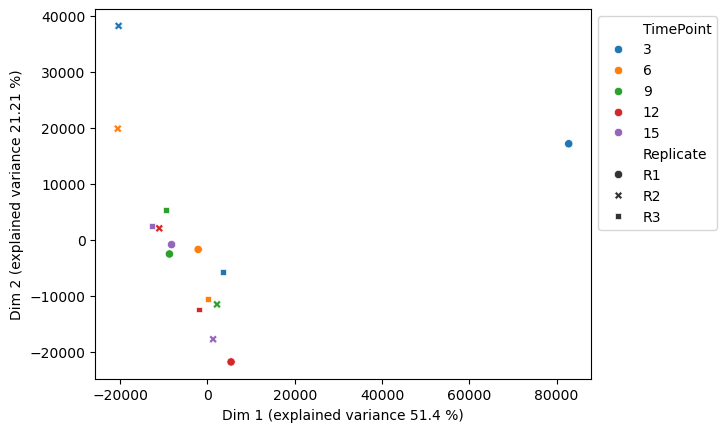

In [38]:
txPCA(tpms[columnOrder])

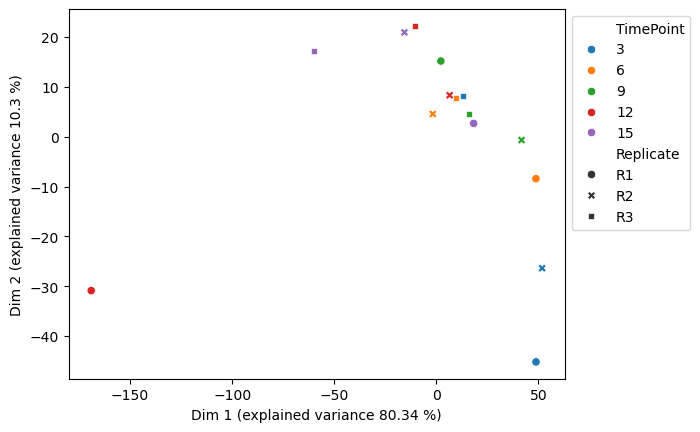

In [39]:
txPCA(logs[columnOrder])

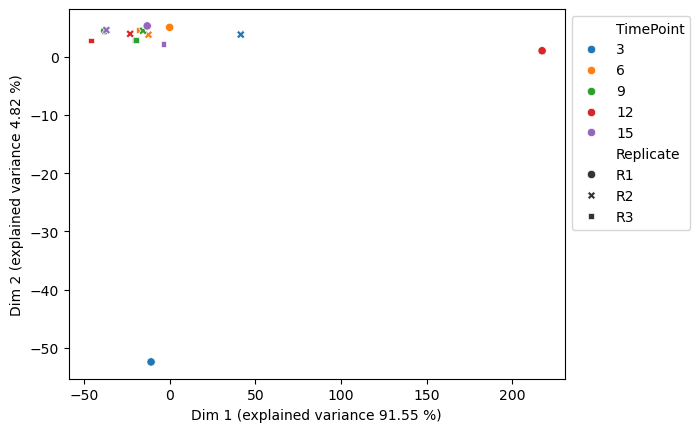

In [40]:
txPCA(logTPMs[columnOrder])

In [41]:
tpmHost = tpms[tpms['Entity'] == 'host']
tpmPhage = tpms[tpms['Entity'] == 'phage']
logTPMsHost = logTPMs[logTPMs['Entity'] == 'host']
logTPMsPhage = logTPMs[logTPMs['Entity'] == 'phage']

In [42]:
logTPMs

SampleNames,3_R1,3_R2,3_R3,6_R1,6_R2,6_R3,9_R1,9_R2,9_R3,12_R1,12_R2,12_R3,15_R1,15_R2,15_R3,Entity,Symbol
Geneid,,,,,,,,,,,,,,,,,
gene-SynWH7803_2108,1.178744,4.357823,2.455453,2.954191,2.936082,2.813895,1.887615,2.291872,2.405820,9.170269,2.204870,2.079073,2.578618,2.612693,2.006883,host,gene-SynWH7803_2108
gene-SynWH7803_1766,3.154615,3.204694,1.965984,2.158343,2.080724,1.936808,1.357367,1.892288,1.881768,7.100951,1.982454,1.552738,1.740309,1.807983,2.232525,host,cobD/cbiB
gene-SynWH7803_0766,2.086789,3.901313,2.480974,3.037028,2.880080,2.587286,2.417944,2.970081,2.686409,7.256332,2.508926,1.868026,2.834876,1.760736,2.651120,host,gene-SynWH7803_0766
gene-RNA_26,2.769434,3.999179,2.936505,2.578113,2.434818,2.446429,2.318622,2.386661,3.158473,4.778371,2.155172,2.030651,2.026993,2.616285,2.090165,host,gene-RNA_26
gene-SynWH7803_1224,3.587065,4.879822,3.297778,3.789405,2.911841,3.359460,3.613187,4.108098,3.685647,8.832130,3.241447,2.773228,3.383039,2.847223,3.358926,host,psaK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-S-PM2p235,12.273849,12.232401,12.596209,12.648615,12.900620,12.488909,12.967922,12.599539,12.847862,11.637386,13.354822,12.841030,12.899956,12.659228,12.318424,phage,gene-S-PM2p235
gene-SynWH7803_0433,4.435131,3.420841,2.390175,2.453081,2.623738,2.418374,1.770287,2.218717,2.259003,7.075072,2.263224,1.996965,2.294725,2.113943,2.843109,host,rplD
gene-SynWH7803_1838,2.433059,3.125804,2.187681,2.968740,2.636401,2.570253,2.049524,2.619187,1.964396,6.412213,2.595932,1.511242,2.921808,2.491848,2.825834,host,gene-SynWH7803_1838


tpmHost

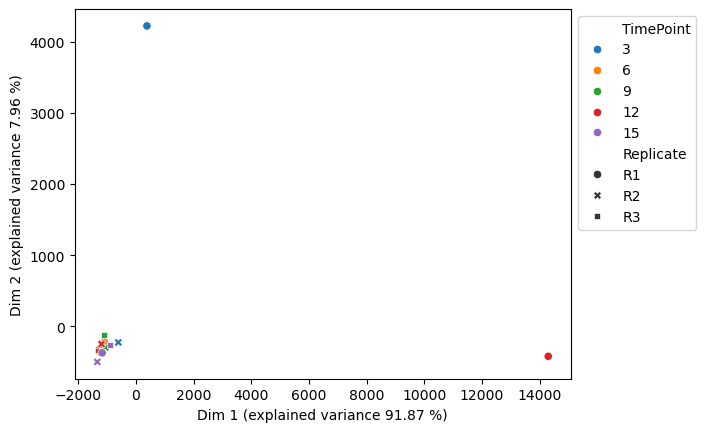

In [43]:
txPCA(tpmHost[columnOrder])

tpmPhage

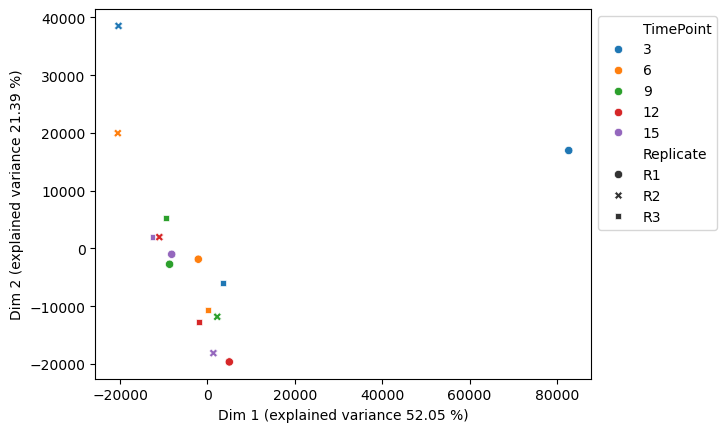

In [44]:
txPCA(tpmPhage[columnOrder])

logTPM Host

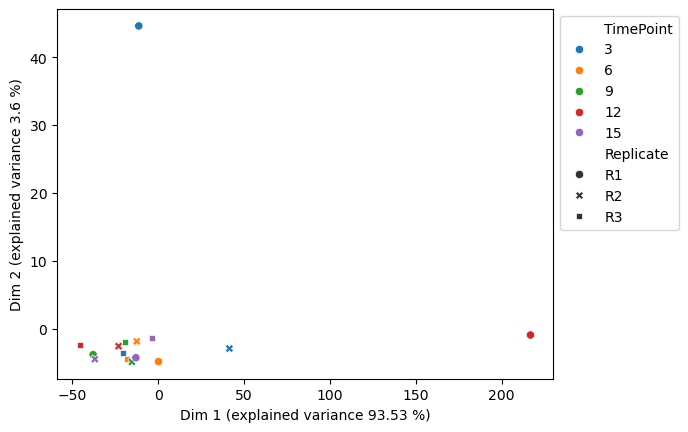

In [45]:
txPCA(logTPMsHost[columnOrder])

logTPM Phage

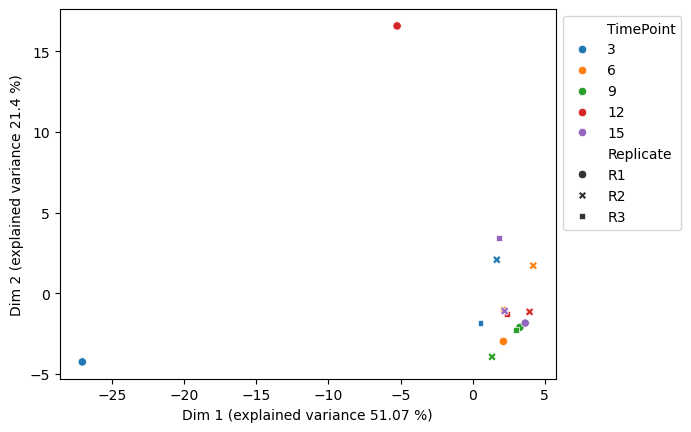

In [46]:
txPCA(logTPMsPhage[columnOrder])

$\rightarrow$ Replicates seem to be fine (not perfect, but no clear outliers detectable)

## 4. Final grouping

Summarize time points with mean and standard deviation for TPM-normalized data.

In [42]:
TPMmeans, TPMsds = getMeanSD(tpms[columnOrder])
TPMmeans = TPMmeans[['0', '2.5', '5', '10', '20', '30']]
TPMmeans[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
TPMmeans

,0,2.5,5,10,20,30,Entity,Symbol
Geneid,,,,,,,,
gene-b3967,35.642440,21.697947,6.988195,4.364323,2.205122,3.881652,host,murI
gene-T4p149,0.224808,25.543714,57.973792,221.439698,1600.740481,2470.430667,phage,5.3
gene-b2180,15.098346,16.772913,6.266603,3.798834,1.512421,2.157329,host,yejF
gene-b1573,5.446411,3.694872,1.851913,1.885777,0.732110,0.506916,host,ydfC
gene-b1619,11.716519,7.471203,2.904576,1.367406,0.827653,1.723104,host,hdhA
...,...,...,...,...,...,...,...,...
gene-b1007,9.423697,8.121292,4.517189,1.383714,1.068802,1.380636,host,rutF
gene-b0793,5.383970,5.127644,2.058530,1.436180,0.679332,0.792528,host,ybhS
gene-b1976,8.874235,3.918718,2.003091,0.662241,0.658546,1.413319,host,mtfA


In [43]:
TPMsds = TPMsds[['0', '2.5', '5', '10', '20', '30']]
TPMsds[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]
TPMsds

,0,2.5,5,10,20,30,Entity,Symbol
Geneid,,,,,,,,
gene-b3967,9.921586,4.006848,2.231663,1.628803,0.370059,3.043935,host,murI
gene-T4p149,0.153654,23.755942,54.378374,185.038235,594.866936,96.831159,phage,5.3
gene-b2180,6.672927,4.733832,3.039424,1.750075,0.254053,1.122259,host,yejF
gene-b1573,0.168305,1.290597,0.916120,0.832950,0.219106,0.046821,host,ydfC
gene-b1619,3.367258,0.888025,0.884657,0.112640,0.001302,1.277027,host,hdhA
...,...,...,...,...,...,...,...,...
gene-b1007,4.827114,0.789703,2.521114,0.180883,0.217333,0.824245,host,rutF
gene-b0793,0.265926,0.159586,0.142877,0.529283,0.316068,0.383798,host,ybhS
gene-b1976,0.289950,0.733136,0.513702,0.323097,0.045387,0.866163,host,mtfA


In [44]:
propExp = proportionalExp(TPMmeans[['0', '2.5', '5', '10', '20', '30']])
propExp[['Entity', 'Symbol']] = TPMmeans[['Entity', 'Symbol']]
propExp

,0,2.5,5,10,20,30,Entity,Symbol
Geneid,,,,,,,,
gene-b3967,1.000000,0.608767,0.196064,0.122447,0.061868,0.108905,host,murI
gene-T4p149,0.000091,0.010340,0.023467,0.089636,0.647960,1.000000,phage,5.3
gene-b2180,0.900162,1.000000,0.373614,0.226486,0.090170,0.128620,host,yejF
gene-b1573,1.000000,0.678405,0.340025,0.346242,0.134421,0.093073,host,ydfC
gene-b1619,1.000000,0.637664,0.247904,0.116708,0.070640,0.147066,host,hdhA
...,...,...,...,...,...,...,...,...
gene-b1007,1.000000,0.861795,0.479344,0.146833,0.113416,0.146507,host,rutF
gene-b0793,1.000000,0.952391,0.382344,0.266751,0.126177,0.147201,host,ybhS
gene-b1976,1.000000,0.441584,0.225720,0.074625,0.074209,0.159261,host,mtfA


## 5. Phage gene classification

In [45]:
# Add a classification label based on exceeding 20 % of maximal expression

def classLabelThreshold(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-2)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM*0.2

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x >= thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('early')
        elif timePoint == 3:
            labels.append('middle')
        elif timePoint == 4:
            labels.append('late')
        elif timePoint == 5:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassThreshold'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassThreshold'] = 'None'

    return tpmOut

In [46]:
# Export fractional expressions with T=0.6 + Host/Phage Annotation for Orthofinder Analysis
# t = classLabelThreshold(propExp)
# t = t[t["Entity"] == "phage"]
# t["Host"] = "Escherichia_Coli_minusToxIN"
# t["Phage"] = "Enterobacteria_phage_T4"
# t.to_csv("/ceph/ibmi/studenten/waffen/Cross_Analysis/Orthofinder_Clustering/Fractional_Expressions/T060/Guegler_T4_minusToxIN_fractional_expression_T=0.6.tsv", sep="\t")

In [47]:
# Add a classification label based on exceeding 20 % of maximal expression

def classLabelMax(tpm):
    
    labels = list()
    
    i = 0
    while i < tpm.shape[0]:

        # Get array of expression values at time points
        expressions = list(tpm.iloc[i,0:(tpm.shape[1]-3)])

        # Get maximal value for each gene across time points
        maxTPM = max(expressions)

        # Get the threshold value
        thresHold = maxTPM

        # Subset expressions based on threshold
        filteredExpressions = [x for x in expressions if x == thresHold]

        # Get index of time point
        indices = [expressions.index(x) for x in filteredExpressions]
        timePoint = min(indices)

        if timePoint == 0:
            labels.append('early')
        elif timePoint == 1:
            labels.append('early')
        elif timePoint == 2:
            labels.append('early')
        elif timePoint == 3:
            labels.append('middle')
        elif timePoint == 4:
            labels.append('late')
        elif timePoint == 5:
            labels.append('late')

        i += 1

    tpmOut = tpm.copy()
    tpmOut['ClassMax'] = labels
    tpmOut.loc[tpmOut['Entity'] == 'host', 'ClassMax'] = 'None'

    return tpmOut

In [48]:
TPMmeans = classLabelThreshold(TPMmeans)
TPMmeans = classLabelMax(TPMmeans)

In [49]:
TPMmeans[TPMmeans['Entity'] == 'phage']['ClassMax'].value_counts()

ClassMax
late      113
early     109
middle     66
Name: count, dtype: int64

In [50]:
t = TPMmeans[TPMmeans["Entity"] == "phage"]
t = t[["Symbol", "ClassThreshold"]]
t.columns = ["gene", "classification"]
t.to_csv("gene_classification_Guegler_2021_T4_minus_toxIN_[0.2].csv", index=False)

Add classes to other dfs.

In [51]:
TPMsds[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
tpms[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
logs[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]
propExp[['ClassThreshold', 'ClassMax']] = TPMmeans[['ClassThreshold', 'ClassMax']]

# gff3
gff3_final = gff3_genes.merge(TPMmeans[["ClassThreshold", "ClassMax"]], right_index=True, left_on="ID", how="left")
gff3_host  = gff3_final[gff3_final['seq_id'] == 'U00096.3']
gff3_phage = gff3_final[gff3_final['seq_id'] == 'NC_000866.4']

## 6. Add variance to all dataframes

Base variance call on tpms.

In [52]:
def stabilizedVariance(df):
    labels = list()
    
    i = 0
    while i < df.shape[0]:

        # Get array of expression values at time points
        expressions = list(df.iloc[i,0:(df.shape[1]-4)])

        # Get mean expression for the gene
        exprMean = np.mean(np.array(expressions))

        # Get the variance for the gene
        varGene = np.var(np.array(expressions))

        # Stabilized variance
        stableVarGene = varGene/exprMean

        labels.append(stableVarGene)

        i += 1

    tpmOut = df.copy()
    tpmOut['Variance'] = labels

    return tpmOut

In [53]:
tpms = stabilizedVariance(tpms)
tpms

SampleNames,0_R1,0_R2,2.5_R1,2.5_R2,5_R1,5_R2,10_R1,10_R2,20_R1,20_R2,30_R1,30_R2,Entity,Symbol,ClassThreshold,ClassMax,Variance
Geneid,,,,,,,,,,,,,,,,,
gene-b3967,25.720854,45.564027,25.704795,17.691099,9.219858,4.756533,5.993126,2.735519,2.575181,1.835062,6.925588,0.837717,host,murI,None,None,13.754069
gene-T4p149,0.378462,0.071155,1.787771,49.299656,3.595418,112.352167,36.401463,406.477933,1005.873545,2195.607417,2373.599509,2567.261826,phage,5.3,late,late,1354.409076
gene-b2180,8.425419,21.771272,21.506745,12.039081,9.306027,3.227179,5.548909,2.048760,1.766474,1.258368,3.279587,1.035070,host,yejF,None,None,6.662164
gene-b1573,5.614716,5.278107,4.985468,2.404275,0.935794,2.768033,2.718728,1.052827,0.513003,0.951216,0.553737,0.460095,host,ydfC,None,None,1.498212
gene-b1619,15.083777,8.349261,8.359228,6.583177,3.789233,2.019918,1.480046,1.254767,0.828955,0.826351,3.000131,0.446077,host,hdhA,None,None,4.184929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gene-b1007,14.250811,4.596583,8.910996,7.331589,7.038303,1.996075,1.202831,1.564598,1.286136,0.851469,2.204881,0.556390,host,rutF,None,None,3.838849
gene-b0793,5.649896,5.118044,4.968059,5.287230,1.915654,2.201407,0.906896,1.965463,0.363264,0.995400,1.176325,0.408730,host,ybhS,None,None,1.510806
gene-b1976,9.164185,8.584286,4.651854,3.185582,2.516792,1.489389,0.339144,0.985338,0.703933,0.613159,2.279482,0.547156,host,mtfA,None,None,2.938648


In [54]:
logs['Variance'] = tpms['Variance']
TPMmeans['Variance'] = tpms['Variance']
TPMsds['Variance'] = tpms['Variance']
propExp['Variance'] = tpms['Variance']

## 7. Write data to output

In [55]:
df_norRNAs[['Entity', 'Symbol']] = tpms[['Entity', 'Symbol']]

In [56]:
# Full TPM table
tpms.to_csv('Guegler_T4_minusToxIN_full_TPM.tsv', sep = '\t')
# Full raw_counts table
df_norRNAs.to_csv('Guegler_T4_minusToxIN_full_raw_counts.tsv', sep = '\t')
# Summarized (time point means) TPM table
TPMmeans.to_csv('Guegler_T4_minusToxIN_TPM_means.tsv', sep = '\t')
# Summarized (time point) TPM standard deviation
TPMsds.to_csv('Guegler_T4_minusToxIN_TPM_std.tsv', sep = '\t')
# Proportional expression per gene and time point
propExp.to_csv('Guegler_T4_minusToxIN_fractional_expression.tsv', sep = '\t')
# Processed gff3 file
gff3_host.to_csv('Guegler_T4_minusToxIN_host_gff3.tsv', sep='\t')
gff3_phage.to_csv('Guegler_T4_minusToxIN_phage_gff3.tsv', sep='\t')